PART A — CNN (CIFAR-10)

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import time
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


1. DATA LOADING

In [5]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform)

testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=transform)

trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True)
testloader = torch.utils.data.DataLoader(testset, batch_size=64, shuffle=False)

classes = trainset.classes

100%|██████████| 170M/170M [00:02<00:00, 81.1MB/s]


 2. SIMPLE CNN MODEL

In [6]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)

        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.pool = nn.MaxPool2d(2,2)

        self.fc1 = nn.Linear(64*8*8, 128)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(torch.relu(self.bn1(self.conv1(x))))
        x = self.pool(torch.relu(self.conv2(x)))
        x = x.view(-1, 64*8*8)
        x = torch.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

3. TRAINING FUNCTION

In [7]:
def train_model(model, trainloader, epochs=10):
    model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    train_loss = []
    start = time.time()

    for epoch in range(epochs):
        running_loss = 0
        for images, labels in trainloader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        print(f"Epoch {epoch+1}, Loss: {running_loss/len(trainloader)}")
        train_loss.append(running_loss/len(trainloader))

    print("Training Time:", time.time() - start)
    return train_loss

4. TEST + CONFUSION MATRIX

In [8]:
def evaluate_model(model):
    model.eval()
    correct = 0
    total = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in testloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            correct += (predicted == labels).sum().item()
            total += labels.size(0)

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    acc = 100 * correct / total
    print("Accuracy:", acc)

    cm = confusion_matrix(all_labels, all_preds)
    disp = ConfusionMatrixDisplay(cm, display_labels=classes)
    disp.plot()
    plt.show()

    return acc

5. RUN SIMPLE CNN

Epoch 1, Loss: 1.5092766830683364
Epoch 2, Loss: 1.1718558086763562
Epoch 3, Loss: 1.030083226502094
Epoch 4, Loss: 0.9440692641850933
Epoch 5, Loss: 0.8818827151794872
Epoch 6, Loss: 0.8274900158652869
Epoch 7, Loss: 0.7814196114954741
Epoch 8, Loss: 0.74597057486739
Epoch 9, Loss: 0.7050343669588913
Epoch 10, Loss: 0.6747755612177617
Training Time: 892.82843542099
Accuracy: 71.9


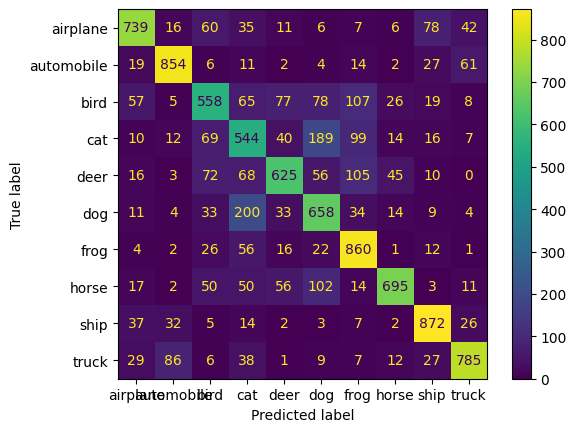

In [9]:
cnn = SimpleCNN()
loss_cnn = train_model(cnn, trainloader, epochs=10)
acc_cnn = evaluate_model(cnn)

6. TRANSFER LEARNING (ResNet18)

Epoch [1/5] Loss: 1.7308
Epoch [2/5] Loss: 1.6038
Epoch [3/5] Loss: 1.5847
Epoch [4/5] Loss: 1.5721
Epoch [5/5] Loss: 1.5670
Accuracy: 43.6


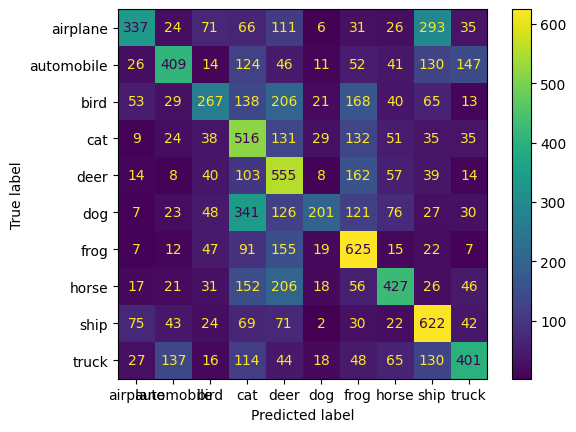

In [10]:
from torchvision.models import resnet18, ResNet18_Weights

# Load pretrained model (correct way)
resnet = resnet18(weights=ResNet18_Weights.DEFAULT)

# Freeze all layers
for param in resnet.parameters():
    param.requires_grad = False

# Replace final layer (this will be trainable)
resnet.fc = nn.Linear(resnet.fc.in_features, 10)

# Move to device
resnet = resnet.to(device)

# IMPORTANT: Only train final layer
optimizer = torch.optim.Adam(resnet.fc.parameters(), lr=0.001)

# Loss function
criterion = nn.CrossEntropyLoss()

# Training loop (custom for transfer learning)
def train_resnet(model, trainloader, epochs=5):
    model.train()
    losses = []

    for epoch in range(epochs):
        running_loss = 0

        for images, labels in trainloader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        epoch_loss = running_loss / len(trainloader)
        losses.append(epoch_loss)

        print(f"Epoch [{epoch+1}/{epochs}] Loss: {epoch_loss:.4f}")

    return losses

# Train
loss_resnet = train_resnet(resnet, trainloader, epochs=5)

# Evaluate (reuse your function)
acc_resnet = evaluate_model(resnet)

7. LOSS GRAPH

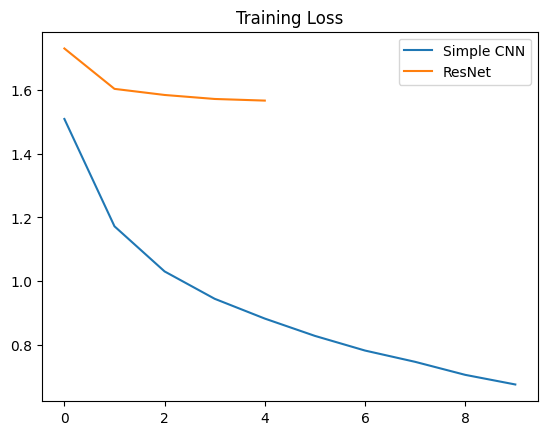

In [11]:
plt.plot(loss_cnn, label="Simple CNN")
plt.plot(loss_resnet, label="ResNet")
plt.legend()
plt.title("Training Loss")
plt.show()